# IMDb Sentiment Classification — BiLSTM + GloVe

**Goal:** Classify movie reviews as Positive or Negative using pre-trained GloVe 100d word vectors fed into a Bidirectional LSTM.

| Setting | Value |
|---|---|
| Dataset | IMDb — 25,000 train / 25,000 test |
| Embedding | GloVe 6B 100d (frozen) |
| Model | Transformer(from scratch) |
| Task | Binary sentiment classification |

## Step 1 — Install & Import

In [9]:
# Run once — installs all required libraries
import subprocess
subprocess.run(['pip', 'install', 'tensorflow', 'numpy', 'matplotlib',
                'seaborn', 'scikit-learn', 'nltk', 'lime', 'torch'], check=True)

CompletedProcess(args=['pip', 'install', 'tensorflow', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'nltk', 'lime', 'torch'], returncode=0)

In [10]:
import re, random, string, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import tensorflow as tf

from nltk.corpus              import stopwords
from nltk.tokenize            import word_tokenize
from tensorflow.keras.datasets              import imdb
from tensorflow.keras.preprocessing.text   import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
#from tensorflow.keras         import layers, Model
#from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics          import (classification_report,
                                      confusion_matrix,
                                      roc_curve, auc, f1_score)
from lime.lime_text           import LimeTextExplainer

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

import sys, torch, torch.nn as nn

# ── Global settings ──────────────────────────────────────────────
MAX_WORDS     = 20000   # vocabulary size
MAX_LEN       = 300     # pad/truncate all reviews to this length
EMBED_DIM     = 100     # must match glove.6B.100d
BATCH_SIZE    = 64
EPOCHS        = 1
GLOVE_PATH    = r'glove.6B\glove.6B.100d.txt'  
STOP_WORDS    = set(stopwords.words('english'))
D_MODEL  = 128   # transformer hidden dim (divisible by N_HEADS)
N_HEADS  = 4
N_LAYERS = 2
D_FF     = 256
DROPOUT  = 0.3

print('All imports successful ✓')

All imports successful ✓


## Step 2 — Load & Clean IMDb Data

IMDb comes as integer sequences. We decode them back to text, then clean with NLTK:
- Lowercase everything
- Strip HTML tags
- Remove punctuation and digits
- Drop stopwords ("the", "is", "a"...)
- Keep only words longer than 2 characters

In [ ]:
# Load raw integer-encoded reviews
(x_tr_enc, y_train), (x_te_enc, y_test) = imdb.load_data(num_words=MAX_WORDS)
y_train, y_test = np.array(y_train), np.array(y_test)

# Decode integers → readable text (correct v+3 offset)
word_index = imdb.get_word_index()
idx2word   = {v + 3: k for k, v in word_index.items()}
idx2word.update({0: '<PAD>', 1: '<START>', 2: '<UNK>', 3: '<UNUSED>'})

def decode_review(seq):
    return ' '.join(idx2word.get(i, '<UNK>') for i in seq)

# NLTK cleaning pipeline
def clean_text(text):
    text   = text.lower()
    text   = re.sub(r'<[^>]+>', ' ', text)   # remove HTML
    text   = re.sub(r'[^a-z\s]', ' ', text)  # keep letters only
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print('Decoding...')
X_train_raw   = [decode_review(s) for s in x_tr_enc]
X_test_raw    = [decode_review(s) for s in x_te_enc]

print('Cleaning with NLTK...')
X_train_clean = [clean_text(r) for r in X_train_raw]
X_test_clean  = [clean_text(r) for r in X_test_raw]

print(f'Train: {len(X_train_clean)}  Test: {len(X_test_clean)}')
print(f'\nSample raw   : {X_train_raw[0][:80]}')
print(f'Sample clean : {X_train_clean[0][:80]}')
print(f'Label        : {"Positive" if y_train[0]==1 else "Negative"}')

c:\Users\kaurh\OneDrive\Desktop\BTP-NLP\nlp_env\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


## Step 3 — Tokenize & Pad

- **Tokenizer** assigns an integer ID to each word (e.g. "film" → 302)
- **`<OOV>`** catches words not in the top 20,000
- **Padding** makes every review exactly 300 tokens long

X_train shape : (25000, 300)
X_test  shape : (25000, 300)
Vocabulary    : 18,649 words


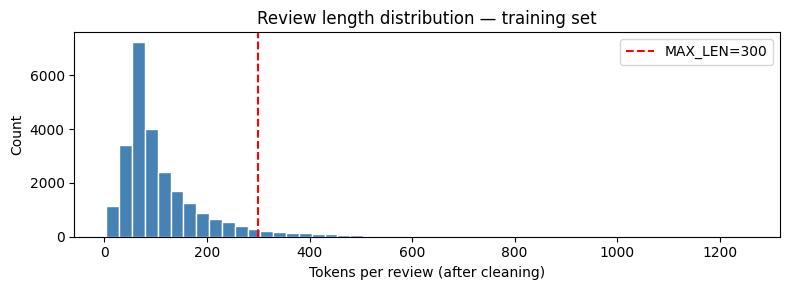

Reviews fully within MAX_LEN: 95.6%


In [ ]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_clean)

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_clean),
                         maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(tokenizer.texts_to_sequences(X_test_clean),
                         maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train shape : {X_train.shape}')  # (25000, 300)
print(f'X_test  shape : {X_test.shape}')   # (25000, 300)
print(f'Vocabulary    : {min(MAX_WORDS, len(tokenizer.word_index)+1):,} words')

# Show review length distribution
lengths = [len(s) for s in tokenizer.texts_to_sequences(X_train_clean)]
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.xlabel('Tokens per review (after cleaning)')
plt.ylabel('Count')
plt.title('Review length distribution — training set')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Reviews fully within MAX_LEN: '
      f'{sum(l<=MAX_LEN for l in lengths)/len(lengths):.1%}')

## Step 4 — Load GloVe & Build Embedding Matrix

`glove.6B.100d.txt` contains 400,000 words, each with 100 pre-trained numbers.
We build a matrix where **row i = the GloVe vector for the word at tokenizer index i**.
Words not found in GloVe stay as zero vectors.

In [ ]:
print(f'Loading GloVe from {GLOVE_PATH} ...')
glove = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype='float32')
print(f'GloVe loaded: {len(glove):,} vectors')

vocab_size      = min(MAX_WORDS, len(tokenizer.word_index) + 1)
embed_matrix    = np.zeros((vocab_size, EMBED_DIM), dtype='float32')
hits, misses    = 0, 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    vec = glove.get(word)
    if vec is not None:
        embed_matrix[idx] = vec
        hits += 1
    else:
        misses += 1

print(f'\nEmbedding matrix : {embed_matrix.shape}')
print(f'GloVe coverage   : {hits:,} hits / {misses:,} misses '
      f'({hits/(hits+misses):.1%})')

Loading GloVe from glove.6B\glove.6B.100d.txt ...
GloVe loaded: 400,000 vectors

Embedding matrix : (18649, 100)
GloVe coverage   : 18,538 hits / 110 misses (99.4%)


## Transformer Build
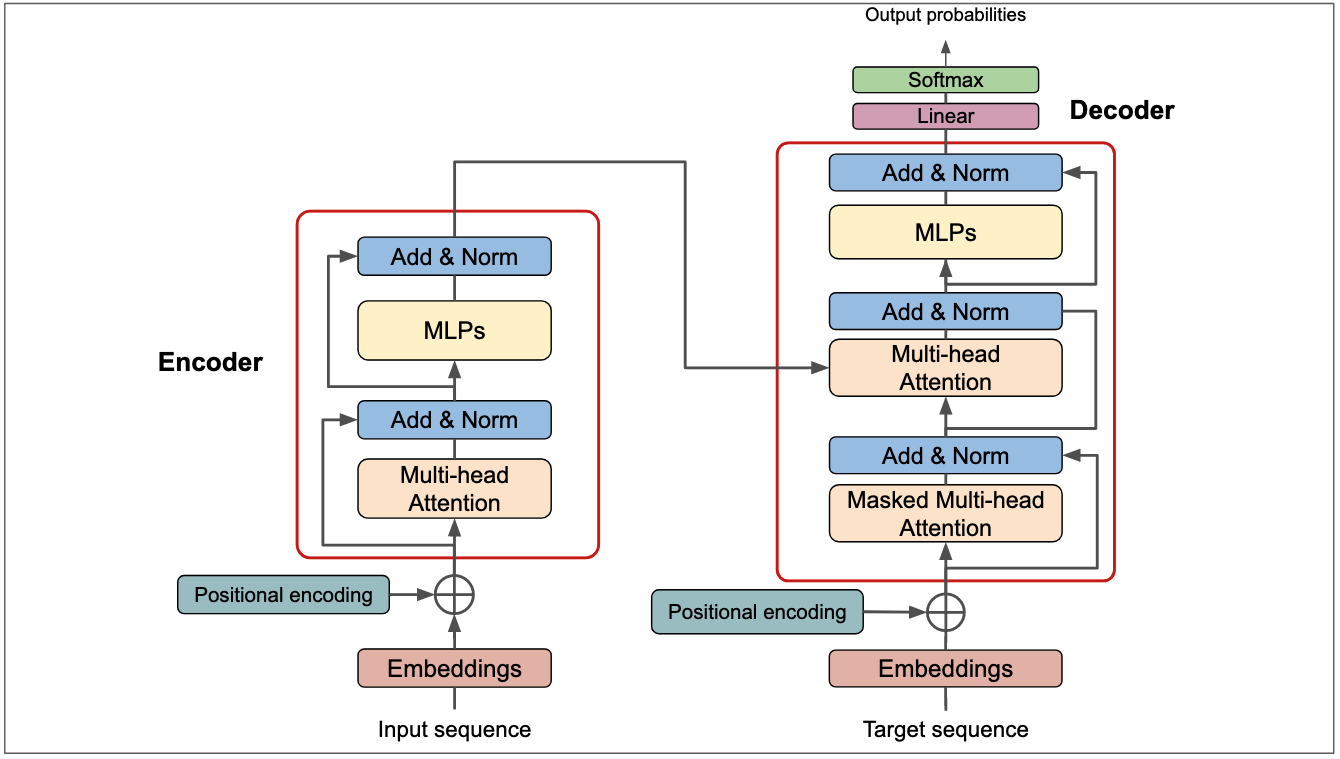

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_matrix):
        super().__init__()
        # Frozen GloVe embedding
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.FloatTensor(embed_matrix), requires_grad=False)
        # Project GloVe 100d → D_MODEL
        self.input_proj = nn.Linear(EMBED_DIM, D_MODEL)
        # PyTorch Transformer Encoder
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=N_HEADS, 
                                       dim_feedforward=D_FF, dropout=DROPOUT, 
                                       batch_first=True),
            num_layers=N_LAYERS
        )
        self.dropout = nn.Dropout(DROPOUT)
        self.fc      = nn.Linear(D_MODEL, 1)

    def forward(self, x):
        x = self.embedding(x)      # (B, 300, 100)
        x = self.input_proj(x)     # (B, 300, 128)
        x = self.encoder(x)        # (B, 300, 128)
        x = x.mean(dim=1)          # (B, 128)  — global average pooling
        x = self.dropout(x)
        return torch.sigmoid(self.fc(x)).squeeze(-1)  # (B,)

model = TransformerClassifier(vocab_size, embed_matrix)
print(model)
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

TransformerClassifier(
  (embedding): Embedding(18649, 100, padding_idx=0)
  (input_proj): Linear(in_features=100, out_features=128, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Trainable params: 278,017


## Step 6 — Train

- `validation_split=0.1` — holds back 10% of training data to monitor overfitting
- `EarlyStopping` — stops training if val_accuracy doesn't improve for 3 epochs and restores the best weights

In [ ]:
X_tr = torch.LongTensor(X_train)
X_te = torch.LongTensor(X_test)
y_tr = torch.FloatTensor(y_train)
y_te = torch.FloatTensor(y_test)

train_ds = torch.utils.data.TensorDataset(X_tr, y_tr)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = torch.utils.data.TensorDataset(X_te[:2500], y_te[:2500])
val_dl   = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE)

optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn    = nn.BCELoss()
best_val, history = 0, {'accuracy': [], 'val_accuracy': []}


def eval_loader_accuracy(model, data_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in data_loader:
            preds = (model(xb) > 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    return correct / total

for epoch in range(EPOCHS):
    print(f'Epoch {epoch+1}/{EPOCHS}')
    model.train()
    total_batches = len(train_dl)
    for batch_idx, (xb, yb) in enumerate(train_dl, start=1):
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        if batch_idx % 10 == 0 or batch_idx == total_batches:
            end_char = '\n' if batch_idx == total_batches else '\r'
            print(f'  batch {batch_idx}/{total_batches}  loss={loss.item():.4f}', end=end_char, flush=True)

    tr_acc = eval_loader_accuracy(model, train_dl)
    va_acc = eval_loader_accuracy(model, val_dl)
    history['accuracy'].append(tr_acc)
    history['val_accuracy'].append(va_acc)
    print(f'Epoch {epoch+1}/{EPOCHS}  train_acc={tr_acc:.4f}  val_acc={va_acc:.4f}')

print('\nTraining complete ✓')

Epoch 1/10


KeyboardInterrupt: 

## Step 7 — Evaluate: Accuracy, F1


In [ ]:
def predict_probs(model, X, batch_size=256):
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.LongTensor(X[i:i+batch_size])
            out = model(xb).cpu().numpy()
            probs.append(out)
    return np.concatenate(probs)

# ── Predictions ───────────────────────────────────────────────────
y_prob = predict_probs(model, X_test, batch_size=256)
y_pred = (y_prob > 0.5).astype(int)
acc    = (y_pred == y_test).mean()

# ── Core metric: F1 ───────────────────────────────────────────────
f1 = f1_score(y_test, y_pred)

print('=' * 44)
print('  Transformer + GloVe 100d — Test Results')
print('=' * 44)
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1-Score  : {f1:.4f}')   # <-- primary metric
print('=' * 44)
print()
print(classification_report(y_test, y_pred,
                             target_names=['Negative', 'Positive']))

# ── Figure: Training curves + Confusion matrix (2 plots, no ROC) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training curves
ax = axes[0]
ax.plot(history['accuracy'],     color='steelblue', linewidth=2, label='Train')
ax.plot(history['val_accuracy'], color='steelblue', linewidth=2, linestyle='--', label='Validation')
ax.set_title('Training Curves', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.6, 1.0)
ax.legend()
ax.grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Neg', 'Pos'],
            yticklabels=['Neg', 'Pos'],
            linewidths=0.5)
axes[1].set_title(f'Confusion Matrix\nAcc={acc:.4f}  F1={f1:.4f}', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Transformer + GloVe 100d — IMDb Sentiment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

## Step 8 — Noise Robustness Study

We inject three types of synthetic noise at increasing intensities and measure accuracy drop:

| Noise type | What it does | Why it matters |
|---|---|---|
| Char noise | Swap / delete / insert characters in words | Simulates typos |
| Word dropout | Randomly remove entire words | Simulates missing text |
| OOV injection | Replace words with fake strings not in GloVe | Tests unknown word handling |

In [ ]:
random.seed(42)

def char_noise(text, rate=0.1):
    """Swap / delete / insert a character in `rate` fraction of words."""
    words, out = text.split(), []
    for w in words:
        if len(w) > 2 and random.random() < rate:
            op = random.choice(['swap', 'delete', 'insert'])
            i  = random.randint(0, len(w) - 2)
            if op == 'swap':
                l = list(w); l[i], l[i+1] = l[i+1], l[i]; w = ''.join(l)
            elif op == 'delete':
                w = w[:i] + w[i+1:]
            else:
                w = w[:i] + random.choice(string.ascii_lowercase) + w[i:]
        out.append(w)
    return ' '.join(out)

def word_dropout(text, rate=0.1):
    """Randomly remove `rate` fraction of words."""
    words = text.split()
    kept  = [w for w in words if random.random() > rate]
    return ' '.join(kept) if kept else words[0]

def oov_inject(text, rate=0.1):
    """Replace `rate` fraction of words with fake OOV tokens."""
    return ' '.join(
        'zxq' + str(random.randint(100,999))
        if random.random() < rate else w
        for w in text.split()
    )

def encode_noisy(texts, noise_fn, rate):
    """Apply noise, re-tokenize, re-pad."""
    noisy = [noise_fn(t, rate) for t in texts]
    seqs  = tokenizer.texts_to_sequences(noisy)
    return pad_sequences(seqs, maxlen=MAX_LEN,
                         padding='post', truncating='post')

# Quick demo
s = X_test_clean[0][:60]
print('Original     :', s)
print('Char  20%    :', char_noise(s, 0.2))
print('Dropout 20%  :', word_dropout(s, 0.2))
print('OOV   20%    :', oov_inject(s, 0.2))

Original     : please give one miss kristy swanson rest cast rendered terri
Char  20%    : please ive one miss kristy swanson est acst rendered terir
Dropout 20%  : please give one kristy swanson rest rendered terri
OOV   20%    : zxq199 give one miss zxq570 swanson rest cast rendered terri


Running Char noise...
782/782 ━━━━━━━━━━━━━━━━━━━━ 252s 322ms/step - accuracy: 0.8536 - loss: 0.3352
  0% → 0.8536
782/782 ━━━━━━━━━━━━━━━━━━━━ 228s 292ms/step - accuracy: 0.8483 - loss: 0.3420
  5% → 0.8483
782/782 ━━━━━━━━━━━━━━━━━━━━ 233s 298ms/step - accuracy: 0.8443 - loss: 0.3529
  10% → 0.8443
782/782 ━━━━━━━━━━━━━━━━━━━━ 212s 271ms/step - accuracy: 0.8354 - loss: 0.3737
  20% → 0.8354
782/782 ━━━━━━━━━━━━━━━━━━━━ 649s 831ms/step - accuracy: 0.8225 - loss: 0.4007
  30% → 0.8225
782/782 ━━━━━━━━━━━━━━━━━━━━ 327s 418ms/step - accuracy: 0.7962 - loss: 0.4361
  40% → 0.7962
782/782 ━━━━━━━━━━━━━━━━━━━━ 282s 361ms/step - accuracy: 0.7677 - loss: 0.4781
  50% → 0.7677
Running Word dropout...
782/782 ━━━━━━━━━━━━━━━━━━━━ 319s 408ms/step - accuracy: 0.8536 - loss: 0.3352
  0% → 0.8536
782/782 ━━━━━━━━━━━━━━━━━━━━ 303s 388ms/step - accuracy: 0.8490 - loss: 0.3424
  5% → 0.8490
782/782 ━━━━━━━━━━━━━━━━━━━━ 262s 335ms/step - accuracy: 0.8477 - loss: 0.3474
  10% → 0.8477
782/782 ━━━━━━━━━━

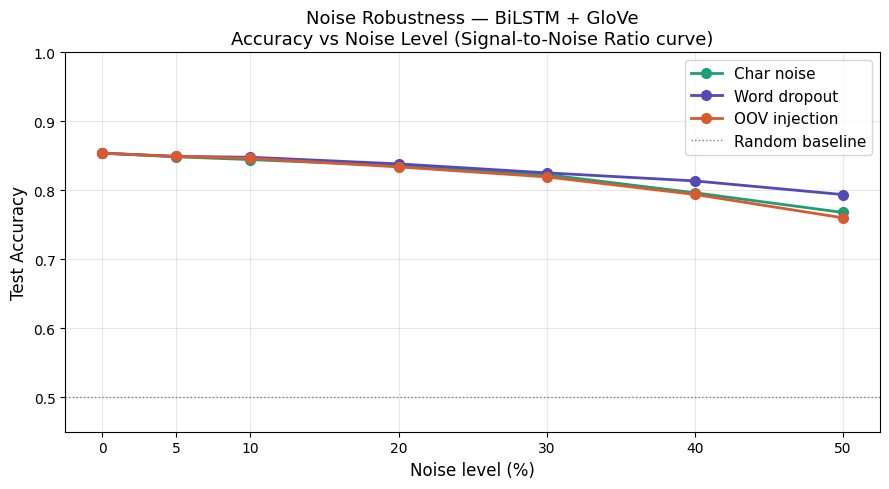


Noise type           Clean    @10%    @30%   Drop@50%
--------------------------------------------------
Char noise          0.8536  0.8443  0.8225    +0.0859
Word dropout        0.8536  0.8477  0.8251    +0.0600
OOV injection       0.8536  0.8461  0.8192    +0.0937


In [ ]:
noise_levels  = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
noise_configs = [
    ('Char noise',    char_noise,    '#1D9E75'),
    ('Word dropout',  word_dropout,  '#534AB7'),
    ('OOV injection', oov_inject,    '#D85A30'),
]

snr_results = {}

for label, fn, _ in noise_configs:
    f1s = []
    print(f'Running {label}...')
    for lvl in noise_levels:
        X_noisy = encode_noisy(X_test_clean, fn, lvl)
        y_prob_noisy = predict_probs(model, X_noisy)
        y_pred_noisy = (y_prob_noisy > 0.5).astype(int).flatten()
        score = f1_score(y_test, y_pred_noisy)   # <-- F1 instead of accuracy
        f1s.append(round(score, 4))
        print(f'  {lvl:.0%} → {score:.4f}')
    snr_results[label] = f1s

# ── Plot SNR curves ───────────────────────────────────────────────
pct = [x * 100 for x in noise_levels]

fig, ax = plt.subplots(figsize=(9, 5))
for (label, _, color) in noise_configs:
    ax.plot(pct, snr_results[label], '-o', color=color,
            linewidth=2, markersize=7, label=label)

ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Random baseline')
ax.set_xlabel('Noise level (%)', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)          # <-- changed from Accuracy
ax.set_title('Noise Robustness — Transformer + GloVe\n'
             'F1-Score vs Noise Level', fontsize=13)   # <-- changed
ax.set_ylim(0.45, 1.00)
ax.set_xticks(pct)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Degradation table ─────────────────────────────────────────────
print(f'\n{"Noise type":<18} {"Clean":>7} {"@10%":>7} {"@30%":>7} {"Drop@50%":>10}')
print('-' * 50)
for label, _, _ in noise_configs:
    vals = snr_results[label]
    print(f'{label:<18} {vals[0]:>7.4f} {vals[2]:>7.4f} '
          f'{vals[4]:>7.4f} {vals[0]-vals[-1]:>+10.4f}')

## Step 9 — Interpretability

### 9A. LIME — Local Explanation
LIME asks: *"which words in this specific review pushed the model toward Positive or Negative?"*
It creates hundreds of modified versions (words removed), runs them through the model, and fits a simple linear model to find which words mattered most.

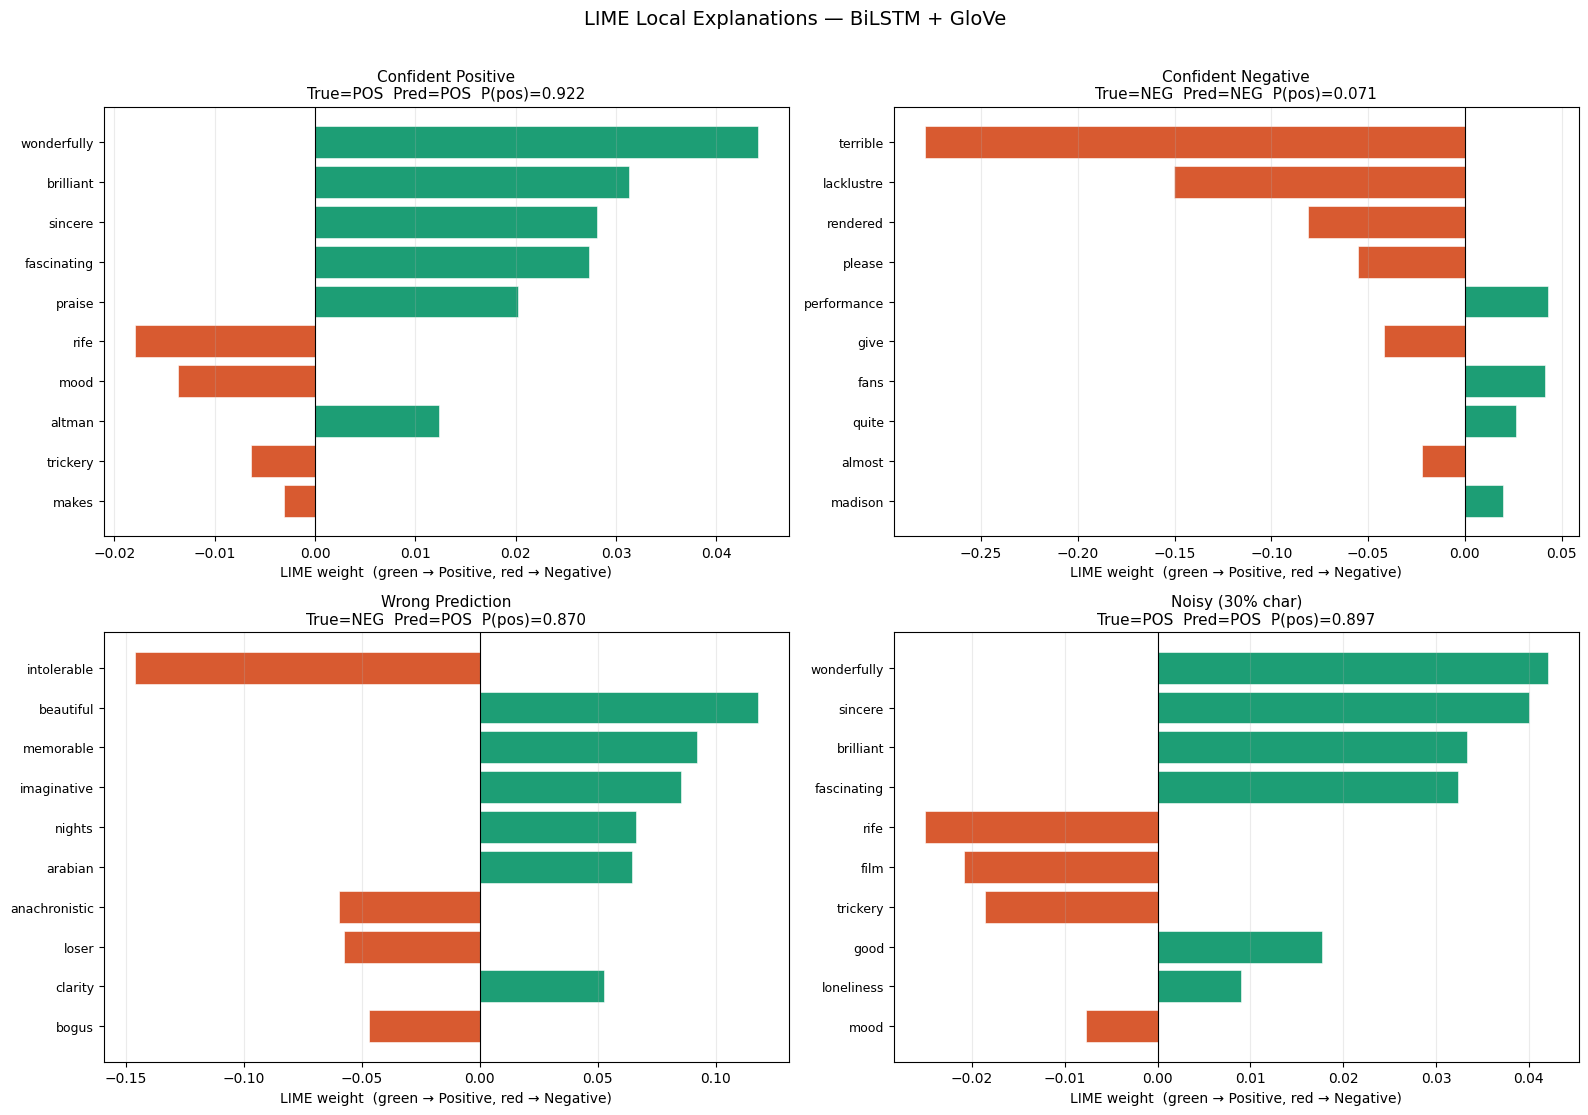

In [ ]:
def pipeline_predict(texts):
    """LIME needs a function: list of raw strings → 2-column probabilities."""
    seqs   = tokenizer.texts_to_sequences([clean_text(t) for t in texts])
    padded = pad_sequences(seqs, maxlen=MAX_LEN,
                            padding='post', truncating='post')
    probs  = predict_probs(model, padded).flatten()
    return np.column_stack([1 - probs, probs])  # [P(neg), P(pos)]

explainer = LimeTextExplainer(class_names=['Negative', 'Positive'])

# Pick 4 examples: confident positive, confident negative,
#                  one wrong prediction, one noisy version
idx_pos   = np.where((y_test == 1) & (y_prob > 0.88))[0][0]
idx_neg   = np.where((y_test == 0) & (y_prob < 0.12))[0][0]
idx_wrong = np.where(y_pred != y_test)[0][0]
noisy_txt = char_noise(X_test_clean[idx_pos], 0.30)

samples = [
    ('Confident Positive',   X_test_clean[idx_pos],   y_test[idx_pos]),
    ('Confident Negative',   X_test_clean[idx_neg],   y_test[idx_neg]),
    ('Wrong Prediction',     X_test_clean[idx_wrong],  y_test[idx_wrong]),
    ('Noisy (30% char)',      noisy_txt,                y_test[idx_pos]),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (title, text, true_lbl) in zip(axes, samples):
    p   = pipeline_predict([text])[0][1]
    exp = explainer.explain_instance(text, pipeline_predict,
                                      num_features=10, num_samples=400)
    pairs = sorted(exp.as_list(), key=lambda x: abs(x[1]), reverse=True)[:10]
    words_, weights_ = zip(*pairs)

    colors_ = ['#1D9E75' if s > 0 else '#D85A30' for s in weights_]
    ax.barh(range(len(words_)), weights_, color=colors_,
            edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(len(words_)))
    ax.set_yticklabels(words_, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME weight  (green → Positive, red → Negative)')
    ax.set_title(
        f'{title}\n'
        f'True={"POS" if true_lbl==1 else "NEG"}  '
        f'Pred={"POS" if p>0.5 else "NEG"}  P(pos)={p:.3f}',
        fontsize=11)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.25)

plt.suptitle('LIME Local Explanations — BiLSTM + GloVe',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 9B. t-SNE — GloVe Vector Space
Compresses 100-dimensional GloVe vectors to 2D so we can *see* that positive words cluster together and negative words cluster apart. This visually proves that GloVe gives the model meaningful word geometry.

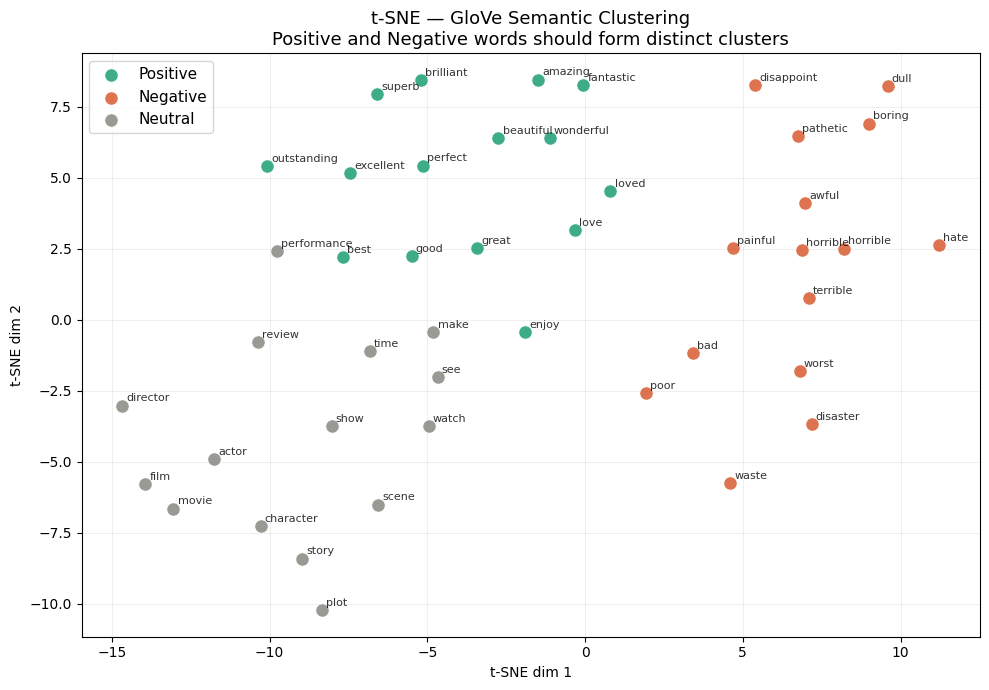

In [ ]:
from sklearn.manifold import TSNE

sentiment_words = {
    'positive': ['good','great','excellent','amazing','brilliant',
                 'wonderful','love','best','perfect','fantastic',
                 'outstanding','superb','enjoy','beautiful','loved'],
    'negative': ['bad','terrible','awful','horrible','boring',
                 'hate','worst','poor','dull','disappoint',
                 'waste','painful','disaster','pathetic','horrible'],
    'neutral' : ['film','movie','watch','scene','story','actor',
                 'plot','time','make','show','see','character',
                 'review','performance','director']
}
color_map = {'positive':'#1D9E75', 'negative':'#D85A30', 'neutral':'#888780'}

word_list, vectors, cat_list = [], [], []
for cat, words in sentiment_words.items():
    for w in words:
        if w in glove:
            word_list.append(w)
            vectors.append(glove[w])
            cat_list.append(cat)

X_vecs = np.array(vectors)
tsne   = TSNE(n_components=2, perplexity=12, max_iter=1500, random_state=42)
X_2d   = tsne.fit_transform(X_vecs)

fig, ax = plt.subplots(figsize=(10, 7))
for cat, color in color_map.items():
    mask = [i for i, c in enumerate(cat_list) if c == cat]
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color, s=90,
               alpha=0.85, label=cat.capitalize(),
               edgecolors='white', linewidths=0.5, zorder=3)
    for i in mask:
        ax.annotate(word_list[i], (X_2d[i,0], X_2d[i,1]),
                    fontsize=8, alpha=0.8,
                    xytext=(3,3), textcoords='offset points')

ax.set_title('t-SNE — GloVe Semantic Clustering\n'
             'Positive and Negative words should form distinct clusters',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.2)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

## Step 10 — Final Summary

        FINAL SUMMARY — BiLSTM + GloVe 100d on IMDb
                     Accuracy F1-Score AUC-ROC Precision Recall
Condition                                                      
Clean test set         0.8536   0.8569  0.9324    0.8378  0.877
Char noise @ 10%       0.8443        —       —         —      —
Char noise @ 30%       0.8225        —       —         —      —
Word dropout @ 10%     0.8477        —       —         —      —
Word dropout @ 30%     0.8251        —       —         —      —
OOV injection @ 10%    0.8461        —       —         —      —
OOV injection @ 30%    0.8192        —       —         —      —


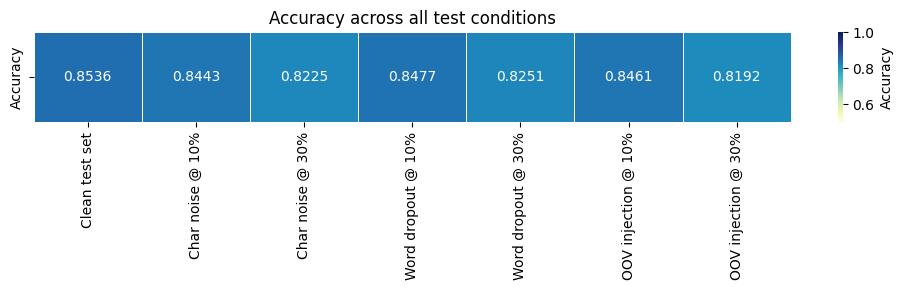


Project complete ✓
  Clean accuracy  : 0.8536
  F1-Score        : 0.8569
  AUC-ROC         : 0.9324
  Best noise drop : Char noise +0.0859


In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score

rows = []
rows.append({
    'Condition' : 'Clean test set',
    'F1-Score'  : round(f1,  4),       # <-- primary metric first
    'Accuracy'  : round(acc, 4),
    'Precision' : round(precision_score(y_test, y_pred), 4),
    'Recall'    : round(recall_score(y_test, y_pred),    4),
})

for label, fn, _ in noise_configs:
    for lvl_idx, lvl_pct in [(2, '10%'), (4, '30%')]:
        rows.append({
            'Condition' : f'{label} @ {lvl_pct}',
            'F1-Score'  : snr_results[label][lvl_idx],   # <-- F1 values
            'Accuracy'  : '—',
            'Precision' : '—',
            'Recall'    : '—',
        })

df = pd.DataFrame(rows).set_index('Condition')

print('=' * 72)
print('        FINAL SUMMARY — Transformer + GloVe 100d on IMDb')  # <-- fixed
print('=' * 72)
print(df.to_string())
print('=' * 72)

# Heatmap on F1-Score column
fig, ax = plt.subplots(figsize=(10, 3))
numeric = df[['F1-Score']].apply(pd.to_numeric, errors='coerce').dropna()
sns.heatmap(numeric.T, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, vmin=0.5, vmax=1.0, ax=ax,
            cbar_kws={'label': 'F1-Score'})
ax.set_title('F1-Score across all test conditions', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nProject complete ✓')
print(f'  F1-Score (primary) : {f1:.4f}')     # <-- F1 first
print(f'  Accuracy           : {acc:.4f}')
print(f'  Best noise drop    : '
      + min(f"{label} {snr_results[label][0]-snr_results[label][-1]:+.4f}"
            for label, _, _ in noise_configs))